# 04 Statistical Analysis 

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

master = pd.read_csv("../data/processed/cleaned_master.csv")

date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

print(f"Loaded— {master.shape[0]:,} rows, {master.shape[1]} columns")

Loaded— 114,092 rows, 43 columns


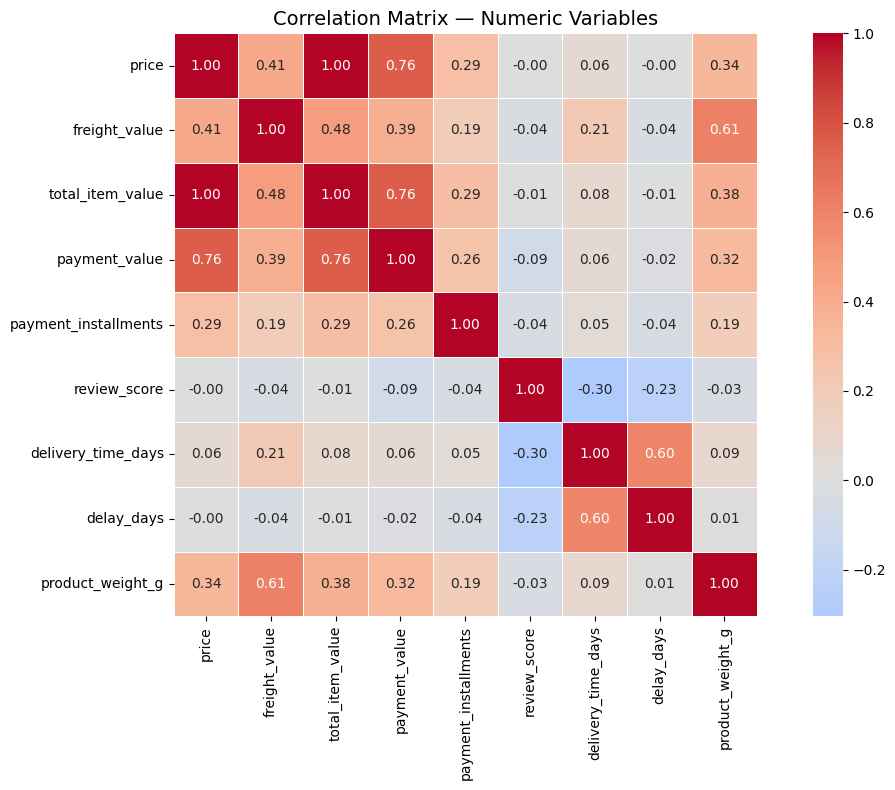

In [5]:
numeric_cols = [
    'price', 'freight_value', 'total_item_value',
    'payment_value', 'payment_installments',
    'review_score', 'delivery_time_days',
    'delay_days', 'product_weight_g'
]
corr_matrix = master[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Variables', fontsize=14)
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png", dpi=150)
plt.show()

In [7]:
corr_price_review = master['price'].corr(master['review_score'])
corr_delivery_review = master['delivery_time_days'].corr(master['review_score'])
corr_weight_freight = master['product_weight_g'].corr(master['freight_value'])

corr_late_review = master['delay_days'].corr(master['review_score'])

print("=" * 50)
print("  KEY CORRELATIONS")
print("=" * 50)
print(f"  Price vs Review Score  : {corr_price_review:+.3f}")
print(f"  Delivery vs Review Score  : {corr_delivery_review:+.3f}")
print(f"  Delay Days vs Review Score  : {corr_late_review:+.3f}")
print(f"  Weight(g) vs Freight Value : {corr_weight_freight:+.3f}")
print("=" * 50)
print("""
  Interpretation Guide:
  +0.5 to +1.0 → Strong positive relationship
  -0.5 to -1.0 → Strong negative relationship
   0.0 to +0.3 → Weak or no relationship
""")

  KEY CORRELATIONS
  Price vs Review Score  : -0.004
  Delivery vs Review Score  : -0.304
  Delay Days vs Review Score  : -0.229
  Weight(g) vs Freight Value : +0.610

  Interpretation Guide:
  +0.5 to +1.0 → Strong positive relationship
  -0.5 to -1.0 → Strong negative relationship
   0.0 to +0.3 → Weak or no relationship



In [8]:
delivered = master[master['order_status'] == 'delivered'].dropna(subset=['is_late', 'review_score'])
on_time_reviews = delivered[delivered['is_late'] == 0]['review_score']
late_reviews    = delivered[delivered['is_late'] == 1]['review_score']
t_stat, p_value = stats.ttest_ind(on_time_reviews, late_reviews)

print("=" * 55)
print("  H1: Late deliveries receive lower review scores")
print("=" * 55)
print(f"  Avg score — On-time : {on_time_reviews.mean():.2f}")
print(f"  Avg score — Late    : {late_reviews.mean():.2f}")
print(f"  Difference          : {on_time_reviews.mean() - late_reviews.mean():.2f} stars")
print(f"  T-statistic         : {t_stat:.4f}")
print(f"  P-value             : {p_value:.6f}")
print("-" * 55)
if p_value < 0.05:
    print("RESULT: Statistically SIGNIFICANT")
    print("Late deliveries DO get worse reviews (p < 0.05)")
else:
    print("RESULT: Not statistically significant")
print("=" * 55)

  H1: Late deliveries receive lower review scores
  Avg score — On-time : 4.21
  Avg score — Late    : 2.55
  Difference          : 1.66 stars
  T-statistic         : 116.0714
  P-value             : 0.000000
-------------------------------------------------------
RESULT: Statistically SIGNIFICANT
Late deliveries DO get worse reviews (p < 0.05)


In [9]:
sp_delivery = delivered[delivered['customer_state'] == 'SP']['delivery_time_days'].dropna()
other_delivery = delivered[delivered['customer_state'] != 'SP']['delivery_time_days'].dropna()
t_stat2, p_value2 = stats.ttest_ind(sp_delivery, other_delivery)

print("=" * 55)
print("  H2: SP customers receive orders faster than others")
print("=" * 55)
print(f"  Avg delivery — SP     : {sp_delivery.mean():.1f} days")
print(f"  Avg delivery — Others : {other_delivery.mean():.1f} days")
print(f"  Difference            : {other_delivery.mean() - sp_delivery.mean():.1f} days faster in SP")
print(f"  T-statistic           : {t_stat2:.4f}")
print(f"  P-value               : {p_value2:.6f}")
print("-" * 55)
if p_value2 < 0.05:
    print("RESULT: Statistically SIGNIFICANT")
    print("SP does deliver significantly faster (p < 0.05)")
else:
    print("RESULT: Not statistically significant")
print("=" * 55)

  H2: SP customers receive orders faster than others
  Avg delivery — SP     : 8.3 days
  Avg delivery — Others : 14.7 days
  Difference            : 6.4 days faster in SP
  T-statistic           : -119.6918
  P-value               : 0.000000
-------------------------------------------------------
RESULT: Statistically SIGNIFICANT
SP does deliver significantly faster (p < 0.05)


In [10]:
credit_orders = master[master['payment_type'] == 'credit_card']['total_item_value']
boleto_orders = master[master['payment_type'] == 'boleto']['total_item_value']

t_stat3, p_value3 = stats.ttest_ind(credit_orders, boleto_orders)

print("=" * 55)
print("  H3: Credit card orders are higher value than boleto")
print("=" * 55)
print(f"  Avg value — Credit Card : BRL {credit_orders.mean():.2f}")
print(f"  Avg value — Boleto      : BRL {boleto_orders.mean():.2f}")
print(f"  T-statistic             : {t_stat3:.4f}")
print(f"  P-value                 : {p_value3:.6f}")
print("-" * 55)
if p_value3 < 0.05:
    print("RESULT: Statistically SIGNIFICANT (p < 0.05)")
else:
    print("RESULT: Not statistically significant")
print("=" * 55)

  H3: Credit card orders are higher value than boleto
  Avg value — Credit Card : BRL 145.95
  Avg value — Boleto      : BRL 124.23
  T-statistic             : nan
  P-value                 : nan
-------------------------------------------------------
RESULT: Not statistically significant


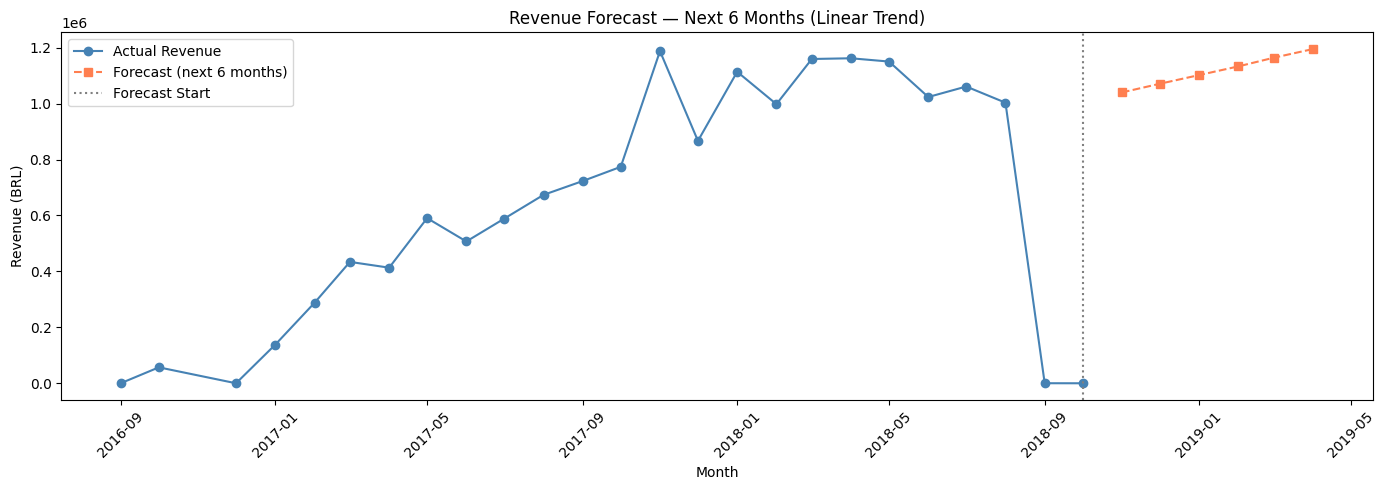


  R² Score (model fit) : 0.281
  Monthly growth trend : BRL +31,033 per month

  Forecasted Revenue:
    Nov 2018 → BRL 1,040,066.11
    Dec 2018 → BRL 1,071,099.28
    Jan 2019 → BRL 1,102,132.45
    Feb 2019 → BRL 1,133,165.62
    Mar 2019 → BRL 1,164,198.79
    Apr 2019 → BRL 1,195,231.96


In [11]:
from numpy.polynomial import polynomial as P
monthly = (master.groupby(['order_year','order_month'])['total_item_value']
           .sum().reset_index())
monthly['period'] = pd.to_datetime({
    'year': monthly['order_year'],
    'month': monthly['order_month'],
    'day': 1
})
monthly = monthly.sort_values('period').reset_index(drop=True)
monthly['t'] = range(len(monthly))

slope, intercept, r, p, se = stats.linregress(monthly['t'], monthly['total_item_value'])
last_t = monthly['t'].max()
last_date = monthly['period'].max()
future_t = range(last_t + 1, last_t + 7)
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=6, freq='MS')
forecast_values = [intercept + slope * t for t in future_t]

plt.figure(figsize=(14, 5))
plt.plot(monthly['period'], monthly['total_item_value'], marker='o',
         color='steelblue', label='Actual Revenue')
plt.plot(future_dates, forecast_values, marker='s', linestyle='--',
         color='coral', label='Forecast (next 6 months)')
plt.axvline(x=last_date, color='gray', linestyle=':', label='Forecast Start')
plt.title('Revenue Forecast — Next 6 Months (Linear Trend)')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/revenue_forecast.png", dpi=150)
plt.show()

print(f"\n  R² Score (model fit) : {r**2:.3f}")
print(f"  Monthly growth trend : BRL {slope:+,.0f} per month\n")
print("  Forecasted Revenue:")
for date, val in zip(future_dates, forecast_values):
    print(f"    {date.strftime('%b %Y')} → BRL {val:>12,.2f}")

In [13]:
snapshot_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (master.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('total_item_value', 'sum')
).reset_index())

rfm['R_score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

print("RFM Segmentation Complete \n")
print(rfm['Segment'].value_counts().to_string())
print(f"\nTotal customers segmented: {len(rfm):,}")

RFM Segmentation Complete 

Segment
Potential Loyalists    32821
Loyal Customers        32015
Champions              15691
At Risk                13978
Lost                    1591

Total customers segmented: 96,096


            Segment  Customers  Avg_Recency  Avg_Orders  Avg_Revenue
          Champions      15691        165.0         1.1        295.6
    Loyal Customers      32015        245.7         1.0        193.8
Potential Loyalists      32821        325.6         1.0        124.4
            At Risk      13978        414.7         1.0         66.0
               Lost       1591        507.9         1.0         41.6


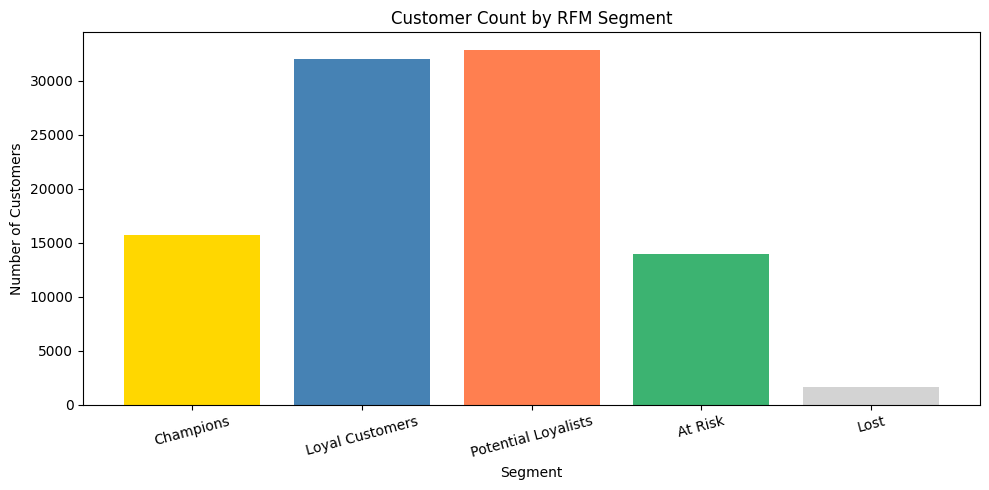

In [14]:
seg_summary = rfm.groupby('Segment').agg(
    Customers   = ('customer_unique_id', 'count'),
    Avg_Recency = ('Recency', 'mean'),
    Avg_Orders  = ('Frequency', 'mean'),
    Avg_Revenue = ('Monetary', 'mean')
).round(1).reset_index().sort_values('Avg_Revenue', ascending=False)

print(seg_summary.to_string(index=False))

plt.figure(figsize=(10,5))
colors = ['gold','steelblue','coral','mediumseagreen','lightgray']
plt.bar(seg_summary['Segment'], seg_summary['Customers'], color=colors)
plt.title('Customer Count by RFM Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../reports/rfm_segments.png", dpi=150)
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

reg_data = master[['review_score','delivery_time_days',
                    'delay_days','price','freight_value',
                    'payment_installments']].dropna()

X = reg_data[['delivery_time_days','delay_days',
              'price','freight_value','payment_installments']]
y = reg_data['review_score']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 55)
print("REGRESSION: What drives review scores?")
print("=" * 55)
print(f"R² Score (explanatory power) : {r2:.3f}")
print(f"Mean Absolute Error          : {mae:.3f} stars")
print("\n Feature Coefficients:")
print("(negative = hurts score, positive = helps score)")
print("-" * 55)
for feature, coef in zip(X.columns, model.coef_):
    direction = "↑" if coef > 0 else "↓"
    print(f"  {direction} {feature:<28}: {coef:+.4f}")
print("=" * 55)

REGRESSION: What drives review scores?
R² Score (explanatory power) : 0.100
Mean Absolute Error          : 1.004 stars

 Feature Coefficients:
(negative = hurts score, positive = helps score)
-------------------------------------------------------
  ↓ delivery_time_days          : -0.0375
  ↓ delay_days                  : -0.0100
  ↑ price                       : +0.0002
  ↑ freight_value               : +0.0016
  ↓ payment_installments        : -0.0227


In [17]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 18.7 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
rfm.to_csv("../data/processed/rfm_segments.csv", index=False)
seg_summary.to_csv("../data/processed/rfm_segment_summary.csv", index=False)

forecast_df = pd.DataFrame({
    'month': future_dates,
    'forecasted_revenue': forecast_values
})
forecast_df.to_csv("../data/processed/revenue_forecast.csv", index=False)

print("All statistical outputs saved to data/processed/")
print("\n  Files saved:")
print("    → rfm_segments.csv")
print("    → rfm_segment_summary.csv")
print("    → revenue_forecast.csv")
print("\n  Charts saved to reports/:")
print("    → correlation_matrix.png")
print("    → revenue_forecast.png")
print("    → rfm_segments.png")

All statistical outputs saved to data/processed/

  Files saved:
    → rfm_segments.csv
    → rfm_segment_summary.csv
    → revenue_forecast.csv

  Charts saved to reports/:
    → correlation_matrix.png
    → revenue_forecast.png
    → rfm_segments.png
